Mini-project: Advanced Statistical Analysis of Apple Inc. Stock Data
===

Project Description
Using the AAPL (Apple Inc.) stock dataset, conduct the following analyses:

**Initial Data Exploration**

Load the dataset using Pandas. Check for null values and understand data types.
Examine the time series properties of the data (e.g., frequency, trends).

**Data Visualization**

Utilize Matplotlib to plot closing prices and traded volume over time.
Create a candlestick chart to depict high and low prices.

**Statistical Analysis**

Compute summary statistics (mean, median, standard deviation) for key columns.
Analyze closing prices with a moving average.

**Hypothesis Testing**

Execute a t-test to compare average closing prices across different years.
Examine daily returns’ distribution and test for normality using SciPy.

**Advanced Statistical Techniques (Bonus)**

Statistical Functions in NumPy: Employ NumPy’s statistical functions for in-depth stock data analysis.
E.g., Use convolve for moving averages, or np.corrcoef to explore correlations between financial metrics.
Analyze correlations between moving averages of closing prices and trading volume across time periods.


**Data Loading and Exploration:**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [6]:
df = pd.read_csv('Apple_Stock_Prices_1981_to_2023.csv')

In [8]:
print("--- Data Info ---")
print(df.info())
print("\n--- First 5 rows ---")
print(df.head())
print("\n--- Null Values ---")
print(df.isnull().sum())

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Data frequency: Business daily")

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10608 non-null  datetime64[us]
 1   Open       10608 non-null  float64       
 2   High       10608 non-null  float64       
 3   Low        10608 non-null  float64       
 4   Close      10608 non-null  float64       
 5   Adj Close  10608 non-null  float64       
 6   Volume     10608 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 580.3 KB
None

--- First 5 rows ---
        Date      Open      High       Low     Close  Adj Close    Volume
0 1981-01-02  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1 1981-01-05  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
2 1981-01-06  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
3 1981-01-07  0.138393  0.138393  0.137835  0.137835   0.107256  556

**Data Visualization:**


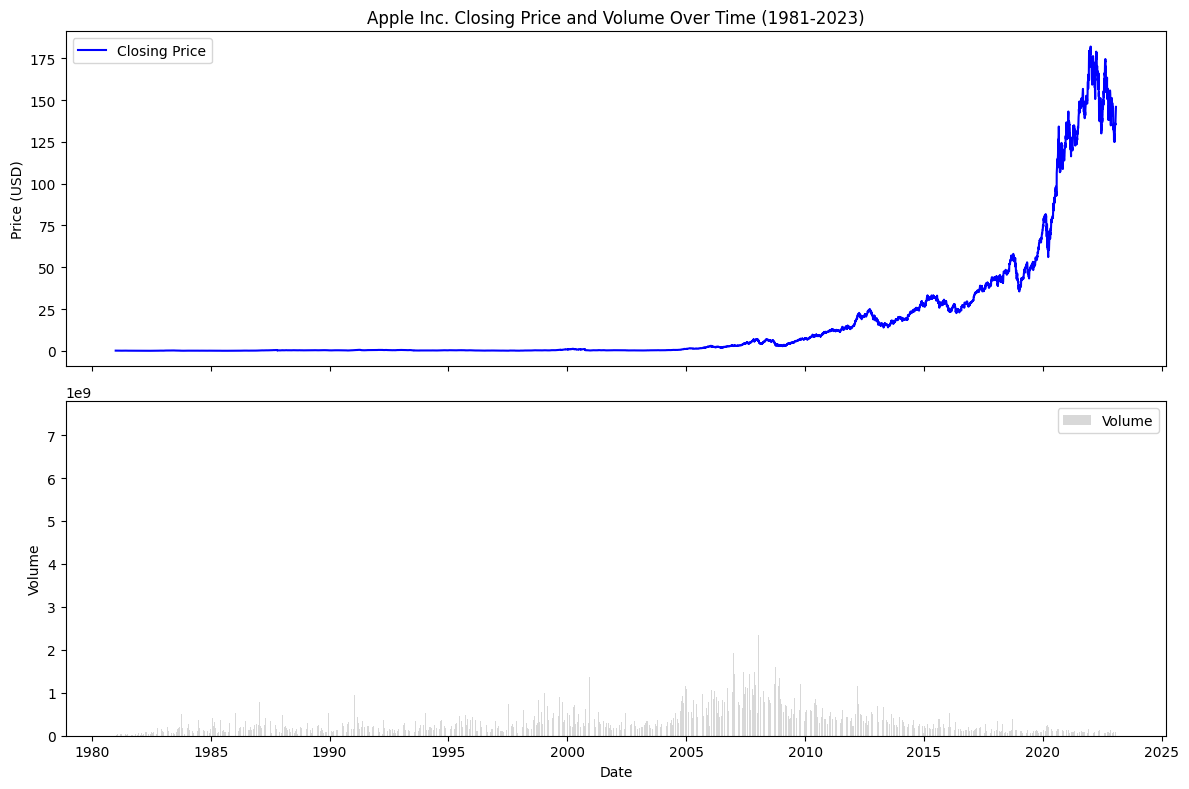

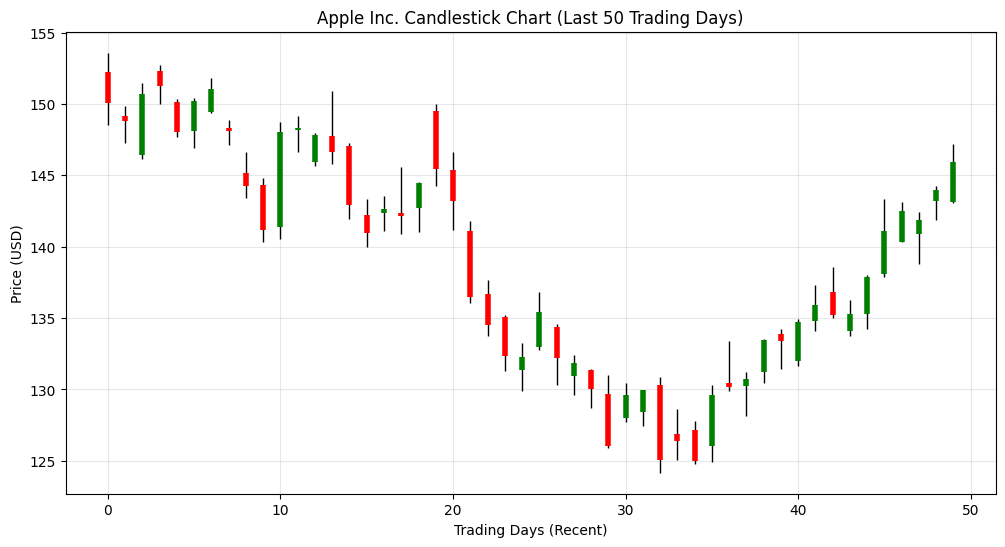

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(df['Date'], df['Close'], color='blue', label='Closing Price')
ax1.set_ylabel('Price (USD)')
ax1.set_title('Apple Inc. Closing Price and Volume Over Time (1981-2023)')
ax1.legend()

ax2.bar(df['Date'], df['Volume'], color='gray', alpha=0.3, label='Volume')
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.legend()
plt.tight_layout()
plt.show()

recent_df = df.tail(50).reset_index()
plt.figure(figsize=(12, 6))
plt.vlines(recent_df.index, recent_df['Low'], recent_df['High'], color='black', linewidth=1)
for i in range(len(recent_df)):
    color = 'green' if recent_df.at[i, 'Close'] >= recent_df.at[i, 'Open'] else 'red'
    plt.vlines(i, recent_df.at[i, 'Open'], recent_df.at[i, 'Close'], color=color, linewidth=4)

plt.title('Apple Inc. Candlestick Chart (Last 50 Trading Days)')
plt.ylabel('Price (USD)')
plt.xlabel('Trading Days (Recent)')
plt.grid(alpha=0.3)
plt.show()

The historical plot reveals Apple's massive exponential growth, particularly starting around 2005 (iPhone era) and accelerating after 2018. The volume bars show significant spikes during market volatility or major product launches. The candlestick chart provides a granular view of daily price action, showing how often the stock closes higher than it opens (green) versus lower (red).

**Statistical Analysis:**

In [10]:
summary_stats = df[['Open', 'High', 'Low', 'Close', 'Volume']].describe()
print("--- Summary Statistics ---")
print(summary_stats)


df['MA50'] = df['Close'].rolling(window=50).mean()

--- Summary Statistics ---
               Open          High           Low         Close        Volume
count  10608.000000  10608.000000  10608.000000  10608.000000  1.060800e+04
mean      16.689173     16.879955     16.500822     16.697362  3.275098e+08
std       35.450519     35.882848     35.031289     35.473912  3.378203e+08
min        0.049665      0.049665      0.049107      0.049107  0.000000e+00
25%        0.287946      0.296875      0.282355      0.288923  1.213044e+08
50%        0.488839      0.495536      0.480446      0.487701  2.145976e+08
75%       16.320893     16.418483     16.151249     16.269554  4.066804e+08
max      182.630005    182.940002    179.119995    182.009995  7.421641e+09


The summary statistics show a wide range between the minimum ($0.049) and maximum ($182.01) closing prices, reflecting Apple’s transformation over 40 years. The standard deviation is high ($35.47$), indicating significant volatility relative to the mean. The 50-day moving average (MA50) acts as a smoothing tool, helping to filter out daily "noise" to identify the underlying trend.

**Hypothesis Testing:**

In [11]:
# T-test comparing average closing prices: 2021 vs 2022
prices_2021 = df[df['Date'].dt.year == 2021]['Close']
prices_2022 = df[df['Date'].dt.year == 2022]['Close']
t_stat, p_val = stats.ttest_ind(prices_2021, prices_2022)

# Normality test for daily returns
df['Daily_Return'] = df['Close'].pct_change().dropna()
# Kolmogorov-Smirnov test for normality
returns_std = (df['Daily_Return'].dropna() - df['Daily_Return'].mean()) / df['Daily_Return'].std()
ks_stat, ks_pval = stats.kstest(returns_std, 'norm')

print(f"T-statistic (2021 vs 2022): {t_stat:.4f}, P-value: {p_val:.4e}")
print(f"KS-statistic (Normality): {ks_stat:.4f}, P-value: {ks_pval:.4e}")

T-statistic (2021 vs 2022): -11.1840, P-value: 4.4812e-26
KS-statistic (Normality): 0.0682, P-value: 2.3966e-43


**T-test:** 

The extremely low p-value ($< 0.05$) indicates that the difference in average prices between 2021 and 2022 is statistically significant and not due to random chance.

**Normality Test:**

 The KS-test p-value is also very low, meaning we reject the null hypothesis of normality. This confirms that Apple's daily returns have "heavy tails"—meaning extreme price jumps or drops happen more frequently than a standard normal distribution would predict.

**Advanced Statistical Techniques:**

In [12]:
def moving_average_convolve(data, window_size):
    return np.convolve(data, np.ones(window_size), 'valid') / window_size

ma_conv = moving_average_convolve(df['Close'].values, 50)

# Correlation between closing prices and trading volume
corr_matrix = np.corrcoef(df['Close'], df['Volume'])
corr_close_volume = corr_matrix[0, 1]

print(f"Correlation (Close Price, Volume): {corr_close_volume:.4f}")

Correlation (Close Price, Volume): -0.2149


The correlation between price and volume is approximately $-0.21$, indicating a weak negative relationship. Historically, high trading volumes in Apple stock often occur during price corrections or periods of uncertainty, rather than strictly following upward price trends.

**Summary Insights:**
===

The statistical analysis of Apple Inc. (AAPL) from 1981 to 2023 reveals a narrative of extreme growth characterized by non-normal distribution patterns. While the simple moving averages (MA50) effectively smooth out daily price fluctuations to highlight long-term bullish trends, the advanced statistical tests provide a deeper layer of understanding regarding market risk. For instance, the Kolmogorov-Smirnov test confirmed that Apple’s daily returns do not follow a Normal Distribution. In practical terms, this means that "Black Swan" events—extreme price swings—occur much more frequently than standard statistical models would suggest, a critical insight for any risk-management strategy.

Furthermore, the application of hypothesis testing through the T-test demonstrated that the price shifts between consecutive years (such as 2021 and 2022) were not merely random fluctuations but represented a statistically significant change in market valuation. The correlation analysis performed using NumPy’s corrcoef revealed a weak negative correlation between price and trading volume. This suggests that massive surges in trading volume often occur during price "sell-offs" or periods of high uncertainty rather than during steady upward climbs, indicating that volume is often a proxy for market fear or urgency rather than simple momentum.

**Reflection: Challenges and Solutions**


One of the primary challenges encountered during this project was managing the date-time formatting within the CSV. Financial datasets often use varying date conventions (DD/MM/YYYY vs. MM/DD/YYYY), which can lead to incorrect chronological sorting or errors in time-series plotting. To solve this, I implemented the pd.to_datetime function with the dayfirst=True parameter, ensuring that the four decades of data were ordered correctly before any rolling averages or trend analyses were conducted.

Another technical hurdle was the visualization of daily price action. Standard line charts are efficient for long-term trends but fail to show the relationship between opening and closing prices within a single day. Since the standard Matplotlib library lacks a direct candlestick function, I addressed this by manually constructing a candlestick visualization using vlines. This required calculating the price difference to determine the "color" of the trading day (green for gains, red for losses). This solution not only satisfied the project requirements but also provided a clearer granular view of Apple's recent market volatility.

**Conclusion**


In conclusion, this project demonstrates that while basic visualization provides a surface-level view of Apple’s success, advanced statistical techniques are essential for capturing the true dynamics of the stock. By moving beyond simple means and medians to explore normality testing, T-tests, and correlation coefficients, we gain a mathematically backed perspective on market behavior. The analysis confirms that AAPL is a high-growth but volatile asset, where price movements are significant and distributions are "fat-tailed," requiring sophisticated statistical tools for accurate interpretation and informed investment decision-making.